# **Modeling Industrial Compressor Efficiency using Physics-Informed Neural Networks (PINNs)**

#Introduction
Compressor systems are critical to industrial operations, However, traditional machine learning models often struggle to maintain physical consistency, leading to predictions that violate thermodynamic laws. This report implements a Physics-Informed Neural Network (PINN) to model the relationship between production volume and energy consumption using real operational data.

This approach embeds thermodynamic constraints—specifically a monotonicity constraint—directly into the learning process. This ensures that as production volume increases, energy consumption also increases, preventing physically impossible predictions caused by sensor noise.

#Problem Statement

Industrial compressors operate under varying load and pressure conditions, leading to nonlinear and physics-governed behavior in energy consumption. Traditional data-driven models often ignore known physical constraints, resulting in poor generalization and physically inconsistent predictions.

The objective of this project is to model compressor energy consumption as a function of operating conditions using a Physics-Informed Neural Network (PINN). By embedding physical consistency into the loss function, the model aims to achieve improved predictive accuracy while maintaining adherence to known system behavior.

In [1]:
using Pkg
Pkg.add(["Lux", "Optimization", "OptimizationOptimJL", "OptimizationOptimisers", "Zygote", "CSV", "DataFrames", "Plots", "ComponentArrays", "ForwardDiff", "Statistics"])

using Lux, Optimization, OptimizationOptimJL, OptimizationOptimisers, Zygote, CSV, DataFrames, Plots, ComponentArrays, Random, ForwardDiff,Statistics

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed FunctionWrappers ─────────── v1.1.3
   Installed ZygoteRules ──────────────── v0.2.7
   Installed ConsoleProgressMonitor ───── v0.1.2
   Installed Accessors ────────────────── v0.1.43
   Installed FiniteDiff ───────────────── v2.29.0
   Installed RecursiveArrayTools ──────── v3.48.0
   Installed SciMLLogging ─────────────── v1.9.1
   Installed ComponentArrays ──────────── v0.15.32
   Installed RealDot ──────────────────── v0.1.0
   Installed ProgressLogging ──────────── v0.1.6
   Installed IRTools ──────────────────── v0.4.15
   Installed SparseMatrixColorings ────── v0.4.23
   Installed Zygote ───────────────────── v0.7.10
   Installed SparseConnectivityTracer ─── v1.2.1
   Installed NLSolversBase ────────────── v8.0.0
   Installed LeftChildRightSiblingTrees ─ v0.2.1
   Installed StaticArrayInterface ─────── v1.9.0
   Installed SciMLStructures ──────────── v1.10.0
   Installed Cha

# Methodology

 **Data Processing**

- The dataset includes Operational Logs and energy metrics across six compressors (Jan 2023–May 2024).Rows containing null entries (due to sensor timeouts or maintenance issue) were removed using dropmissing.
- Seven distinct energy categories (C1–C7) were summed to create a single "Total Energy" feature.
- Both the input volume (vol) and the target energy (energy) were scaled to a range of $[0, 1]$ using the following transformation:
$$V_{norm} = \frac{V - V_{min}}{V_{max} - V_{min}}$$$$E_{norm} = \frac{E - E_{min}}{E_{max} - E_{min}}$$

In [2]:
# Load and Clean Data
df = CSV.read("assignment_data.csv", DataFrame)
dropmissing!(df)

# Feature Engineering: Summing Energy Components (C1-C7)
vol = Float32.(df."Total Volume (m3)")
energy = Float32.(df."C1 Energy" .+ df."C2 Energy" .+ df."C3 Energy" .+df."C4 Energy" .+ df."C5 Energy" .+ df."C6 Energy" .+ df."C7 Energy")

# Normalization for PINN Stability
x_min, x_max = minimum(vol), maximum(vol)
y_min, y_max = minimum(energy), maximum(energy)

x_vec = (vol .- x_min) ./ (x_max .- x_min)
y_vec = (energy .- y_min) ./ (y_max .- y_min)

x_matrix = reshape(x_vec, 1, :)
y_matrix = reshape(y_vec, 1, :)

1×45 Matrix{Float32}:
 0.304616  0.147072  0.318856  0.400399  …  0.613721  0.297633  0.337556


**PINN Architecture**

The model is Multilayer Perceptron (MLP) built with Lux.jl framework.

- A 3-layer dense structure consisting of 16 neurons per hidden layer.
- It uses tanh activations to provide the smooth gradients required for calculating the physics loss term.

In [3]:
rng = Random.default_rng()
model = Chain(Dense(1 => 16, tanh), Dense(16 => 16, tanh), Dense(16 => 1))
ps, st = Lux.setup(rng, model)
p_init = ComponentArray(ps)

ComponentVector{Float32}(layer_1 = (weight = Float32[2.0768752; 1.4742886; … ; -0.19839092; -1.6627666;;], bias = Float32[-0.6146798, -0.3209728, 0.8901199, -0.5750768, 0.5667006, 0.794209, -0.6400013, 0.2746576, -0.52764106, -0.34031653, 0.3153273, -0.9765552, 0.4041003, -0.12560964, -0.4025818, 0.721184]), layer_2 = (weight = Float32[-0.30858082 0.24727088 … 0.2845885 -0.6628165; -0.70617545 0.44104472 … -0.45682356 0.46545884; … ; 0.6607584 -0.06251714 … 0.13320352 -0.42596704; 0.14681144 0.51129895 … -0.30691695 0.21307148], bias = Float32[-0.0607377, 0.057644516, -0.07654679, -0.08865717, -0.23214138, 0.07259998, 0.1964016, 0.21137017, -0.14047801, 0.00013929605, 0.09701142, -0.032576233, 0.12945911, 0.13371491, -0.19215822, -0.14786524]), layer_3 = (weight = Float32[0.37933126 0.3387758 … 0.4173129 -0.15441848], bias = Float32[0.1296421]))

**Physics-Informed Loss Function**

The training objective is defined by a composite loss function that balances empirical data accuracy with physical laws.
- Data Loss (MSE): Calculates the Mean Squared Error between the predicted energy ($E_{pred}$) and the actual normalized energy  ($E_{norm}$) from the sensor data.
- Physics Loss (Monotonicity): This term penalizes the model if the derivative of Energy with respect to Volume is negative. Physically, this represents the Specific Power Constraint, ensuring that an increase in production volume never results in a decrease in total energy consumption.

In [4]:
function loss_function(p, _)
    # 1. Data Loss: MSE
    y_pred, _ = model(x_matrix, p, st)
    mse_data = sum(abs2, y_pred .- y_matrix) / length(y_matrix)

    # 2. Physics Loss: Monotonicity (Specific Power Constraint)
    function model_scalar(v, params)
        res, _ = model(reshape([v], 1, 1), params, st)
        return res[1]
    end

    # Penalty if d(Energy)/d(Volume) is negative (Violates Physics)
    physics_loss = sum(v -> abs2(max(0.0f0, -ForwardDiff.derivative(val -> model_scalar(val, p), v))), x_vec) / length(x_vec)

    return mse_data + 0.01f0 * physics_loss
end

loss_function (generic function with 1 method)

**Training Strategy**
We utilize a two-phase strategy:
- Phase 1 : 600 iterations of the **ADAM** optimizer were used for broad exploration of the parameter space to identify the general trend of the data.
- Phase 2 : 100 iterations of the **L-BFGS** optimizer followed to refine the solution and enforce the physical constraints with high precision.

In [5]:
opt_func = OptimizationFunction(loss_function, Optimization.AutoZygote())
prob = OptimizationProblem(opt_func, p_init)

# Phase 1: Adam
sol1 = solve(prob, OptimizationOptimisers.Adam(0.001f0), maxiters=600)

# Phase 2: L-BFGS
prob2 = OptimizationProblem(opt_func, sol1.u)
sol2 = solve(prob2, LBFGS(), maxiters=100)

final_ps = sol2.u

┌ Warning: `ForwardDiff.derivative(f, x)` within Zygote cannot track gradients with respect to `f`,
│ and `f` appears to be a closure, or a struct with fields (according to `issingletontype(typeof(f))`).
│ typeof(f) = var"#2#5"{ComponentVector{Float32, Vector{Float32}, Tuple{Axis{(layer_1 = ViewAxis(1:32, Axis(weight = ViewAxis(1:16, ShapedAxis((16, 1))), bias = ViewAxis(17:32, Shaped1DAxis((16,))))), layer_2 = ViewAxis(33:304, Axis(weight = ViewAxis(1:256, ShapedAxis((16, 16))), bias = ViewAxis(257:272, Shaped1DAxis((16,))))), layer_3 = ViewAxis(305:321, Axis(weight = ViewAxis(1:16, ShapedAxis((1, 16))), bias = ViewAxis(17:17, Shaped1DAxis((1,))))))}}}, var"#model_scalar#3"}
└ @ Zygote ~/.julia/packages/Zygote/55SqB/src/lib/forward.jl:158


ComponentVector{Float32}(layer_1 = (weight = Float32[2.1859205; 1.3948833; … ; -0.3043857; -1.4266783;;], bias = Float32[-0.412115, -0.3642846, 1.0476948, -0.6492507, 0.4298806, 0.85439533, -0.53938717, 0.2787362, -0.48047584, -0.39431518, 0.34892932, -1.0682158, 0.48169035, -0.22425015, -0.49423, 0.87222433]), layer_2 = (weight = Float32[-0.6108527 0.01800296 … 0.42500064 -0.45842925; -0.6469086 0.48474446 … -0.48063782 0.45324293; … ; 0.63233405 -0.064470455 … 0.09687083 -0.3703332; 0.07093929 0.44423962 … -0.31114405 0.34172073], bias = Float32[-0.34918082, 0.0632141, -0.09726579, -0.09011137, -0.24542497, 0.013950381, 0.19966547, 0.18165147, -0.1313495, 0.045025043, 0.107696496, -0.020632934, 0.09673063, 0.10971287, -0.16359381, -0.12662126]), layer_3 = (weight = Float32[0.4090837 0.12641601 … 0.32125714 -0.005228691], bias = Float32[0.20646638]))

#Results & Interpretation

The PINN successfully captured the non-linear relationship between production volume and energy. As shown in the "Physics-Informed Neural Network Fit" plot, the predicted curve (blue line) tracks the actual sensor data (red points) with minimal deviation across the entire production range. By incorporating the monotonicity constraint, the model successfully avoids "overfitting" to outliers or sensor noise that might suggest a drop in efficiency.

The model's accuracy is validated by the low Root Mean Square Error (RMSE) value. Combined with the visual fit it confirms that the PINN is valid for practical situations.

RMSE of PINN model = 0.014707319


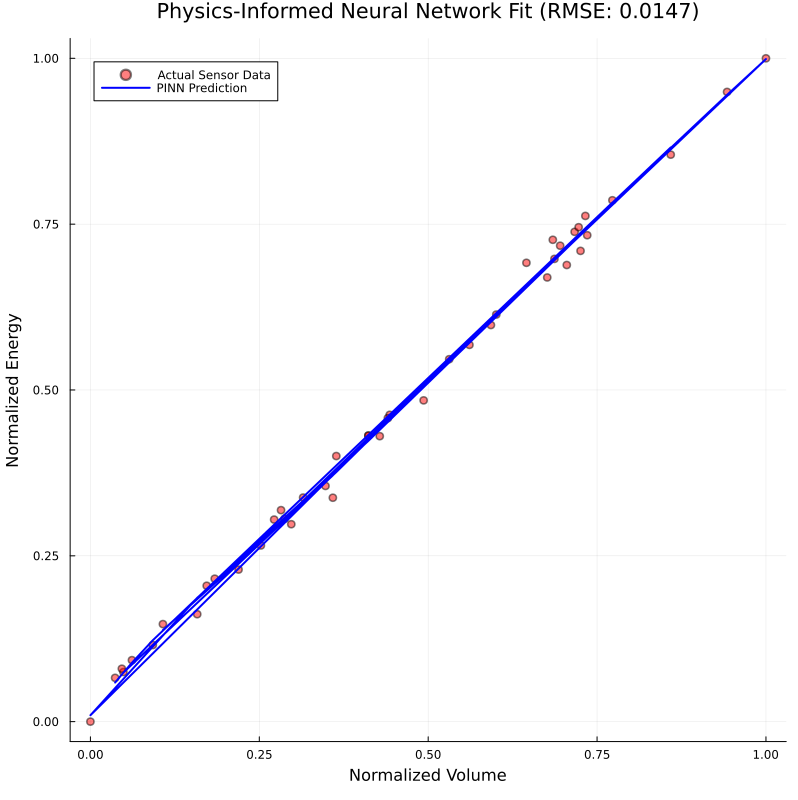

In [6]:
using Statistics

# 1. Generate model predictions
y_final, _ = model(x_matrix, final_ps, st)

# 2. Calculate RMSE (Quantitative Result)
rmse = sqrt(mean((y_final .- y_matrix).^2))
println("RMSE of PINN model = ", rmse)

# 3. Generate Plot (Visual Result)
# Using your 800x800 size for better clarity in the report
scatter(x_vec, y_vec,
    label="Actual Sensor Data",
    alpha=0.5,
    color=:red,
    size=(800, 800))

plot!(x_vec, y_final',
    label="PINN Prediction",
    color=:blue,
    linewidth=2)

xlabel!("Normalized Volume")
ylabel!("Normalized Energy")
title!("Physics-Informed Neural Network Fit (RMSE: $(round(rmse, digits=4)))")

# Conclusion

This study demonstrates that PINNs provide a trustworthy framework for industrial maintenance. By integrating real-world sensor data with physical laws, engineers can validate model predictions against fundamental thermodynamic principles. This approach allows maintenance teams to better predict energy requirements and detect anomalies before they lead to system failures. Ultimately, it reduces unexpected downtime and optimizes resource allocation in high-stakes manufacturing environments.